# Astra Demo

In this demo, we will look at a couple ways to access the astra data products on the BinderHub. By the end of this demo, you will know how to:
- Use `sdss_access` to point to paths on the BinderHub
- Examine stellar parameters for APOGEE and BOSS spectra
- Look at model spectra
- Look at observed spectra from the block file
  
This demo must be run on Rusty to have full access to the files.

First we configure `sdss_access` to work on the BinderHub and load the needed packages for this demo.

In [1]:
# configure sdss_access
import sdss_access.path
import os
os.environ['SAS_BASE_DIR'] = '/home/jovyan/data/release'

# load packages
from astropy.table import Table
import numpy as np
import h5py
import matplotlib.pylab as plt
%matplotlib inline

## APOGEE Model Spectra

In this first demo, we will look at an APOGEE spectrum and its corresponding ASPCAP best-fit model. Data will be drawn from DR19. Below we first create our DR19 path object and then load the ASPCAP summary file.

In [2]:
sdss_path = sdss_access.path.Path(release='dr19',
                                  preserve_envvars=True)

aspcap_path = sdss_path.full('astraAllStarASPCAP', v_astra='0.6.0')

aspcap = Table.read(aspcap_path, hdu=2)


In [3]:
aspcap

sdss_id,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,catalogid25,catalogid31,n_associated,n_neighborhood,sdss5_target_flags,sdss4_apogee_target1_flags,sdss4_apogee_target2_flags,sdss4_apogee2_target1_flags,sdss4_apogee2_target2_flags,sdss4_apogee2_target3_flags,sdss4_apogee_member_flags,sdss4_apogee_extra_target_flags,ra,dec,l,b,plx,e_plx,pmra,e_pmra,pmde,e_pmde,gaia_v_rad,gaia_e_v_rad,g_mag,bp_mag,rp_mag,j_mag,e_j_mag,h_mag,e_h_mag,k_mag,e_k_mag,ph_qual,bl_flg,cc_flg,w1_mag,e_w1_mag,w1_flux,w1_dflux,w1_frac,w2_mag,e_w2_mag,w2_flux,w2_dflux,w2_frac,w1uflags,w2uflags,w1aflags,w2aflags,mag4_5,d4_5m,rms_f4_5,sqf_4_5,mf4_5,csf,zgr_teff,zgr_e_teff,zgr_logg,zgr_e_logg,zgr_fe_h,zgr_e_fe_h,zgr_e,zgr_e_e,zgr_plx,zgr_e_plx,zgr_teff_confidence,zgr_logg_confidence,zgr_fe_h_confidence,zgr_ln_prior,zgr_chi2,zgr_quality_flags,r_med_geo,r_lo_geo,r_hi_geo,r_med_photogeo,r_lo_photogeo,r_hi_photogeo,bailer_jones_flags,ebv,e_ebv,ebv_flags,ebv_zhang_2023,e_ebv_zhang_2023,ebv_sfd,e_ebv_sfd,ebv_rjce_glimpse,e_ebv_rjce_glimpse,ebv_rjce_allwise,e_ebv_rjce_allwise,ebv_bayestar_2019,e_ebv_bayestar_2019,ebv_edenhofer_2023,e_ebv_edenhofer_2023,c_star,u_jkc_mag,u_jkc_mag_flag,b_jkc_mag,b_jkc_mag_flag,v_jkc_mag,v_jkc_mag_flag,r_jkc_mag,r_jkc_mag_flag,i_jkc_mag,i_jkc_mag_flag,u_sdss_mag,u_sdss_mag_flag,g_sdss_mag,g_sdss_mag_flag,r_sdss_mag,r_sdss_mag_flag,i_sdss_mag,i_sdss_mag_flag,z_sdss_mag,z_sdss_mag_flag,y_ps1_mag,y_ps1_mag_flag,n_boss_visits,boss_min_mjd,boss_max_mjd,n_apogee_visits,apogee_min_mjd,apogee_max_mjd,source,star_pk,spectrum_pk,release,filetype,apred,apstar,obj,telescope,field,prefix,min_mjd,max_mjd,n_entries,n_visits,n_good_visits,n_good_rvs,snr,mean_fiber,std_fiber,spectrum_flags,v_rad,e_v_rad,std_v_rad,median_e_v_rad,doppler_teff,doppler_e_teff,doppler_logg,doppler_e_logg,doppler_fe_h,doppler_e_fe_h,doppler_rchi2,doppler_flags,xcorr_v_rad,xcorr_v_rel,xcorr_e_v_rel,ccfwhm,autofwhm,n_components,task_pk,source_pk,v_astra,created,t_elapsed,t_overhead,tag,irfm_teff,irfm_teff_flags,teff,e_teff,logg,e_logg,v_micro,e_v_micro,v_sini,e_v_sini,m_h_atm,e_m_h_atm,alpha_m_atm,e_alpha_m_atm,c_m_atm,e_c_m_atm,n_m_atm,e_n_m_atm,al_h,e_al_h,al_h_flags,al_h_rchi2,c_12_13,e_c_12_13,c_12_13_flags,c_12_13_rchi2,ca_h,e_ca_h,ca_h_flags,ca_h_rchi2,ce_h,e_ce_h,ce_h_flags,ce_h_rchi2,c_1_h,e_c_1_h,c_1_h_flags,c_1_h_rchi2,c_h,e_c_h,c_h_flags,c_h_rchi2,co_h,e_co_h,co_h_flags,co_h_rchi2,cr_h,e_cr_h,cr_h_flags,cr_h_rchi2,cu_h,e_cu_h,cu_h_flags,cu_h_rchi2,fe_h,e_fe_h,fe_h_flags,fe_h_rchi2,k_h,e_k_h,k_h_flags,k_h_rchi2,mg_h,e_mg_h,mg_h_flags,mg_h_rchi2,mn_h,e_mn_h,mn_h_flags,mn_h_rchi2,na_h,e_na_h,na_h_flags,na_h_rchi2,nd_h,e_nd_h,nd_h_flags,nd_h_rchi2,ni_h,e_ni_h,ni_h_flags,ni_h_rchi2,n_h,e_n_h,n_h_flags,n_h_rchi2,o_h,e_o_h,o_h_flags,o_h_rchi2,p_h,e_p_h,p_h_flags,p_h_rchi2,si_h,e_si_h,si_h_flags,si_h_rchi2,s_h,e_s_h,s_h_flags,s_h_rchi2,ti_h,e_ti_h,ti_h_flags,ti_h_rchi2,ti_2_h,e_ti_2_h,ti_2_h_flags,ti_2_h_rchi2,v_h,e_v_h,v_h_flags,v_h_rchi2,short_grid_name,continuum_order,continuum_reject,interpolation_order,initial_flags,rchi2,ferre_log_snr_sq,ferre_time_elapsed,result_flags,flag_warn,flag_bad,stellar_parameters_task_pk,al_h_task_pk,c_12_13_task_pk,ca_h_task_pk,ce_h_task_pk,c_1_h_task_pk,c_h_task_pk,co_h_task_pk,cr_h_task_pk,cu_h_task_pk,fe_h_task_pk,k_h_task_pk,mg_h_task_pk,mn_h_task_pk,na_h_task_pk,nd_h_task_pk,ni_h_task_pk,n_h_task_pk,o_h_task_pk,p_h_task_pk,si_h_task_pk,s_h_task_pk,ti_h_task_pk,ti_2_h_task_pk,v_h_task_pk,calibrated_flags,mass,radius,raw_teff,raw_e_teff,raw_logg,raw_e_logg,raw_v_micro,raw_e_v_micro,raw_v_sini,raw_e_v_sini,raw_m_h_atm,raw_e_m_h_atm,raw_alpha_m_atm,raw_e_alpha_m_atm,raw_c_m_atm,raw_e_c_m_atm,raw_n_m_atm,raw_e_n_m_atm,raw_al_h,raw_e_al_h,raw_c_12_13,raw_e_c_12_13,raw_ca_h,raw_e_ca_h,raw_ce_h,raw_e_ce_h,raw_c_1_h,raw_e_c_1_h,raw_c_h,raw_e_c_h,raw_co_h,raw_e_co_h,raw_cr_h,raw_e_cr_h,raw_cu_h,raw_e_cu_h,raw_fe_h,raw_e_fe_h,raw_k_h,raw_e_k_h,raw_mg_h,raw_e_mg_h,raw_mn_h,raw_e_mn

Let's grab a random star that is hotter than Solar and high SNR.

In [4]:
ev_star = np.where((aspcap['teff'] > 5500) & (aspcap['fe_h'] > 0.) & (~aspcap['flag_bad']) & (aspcap['snr'] > 100))

Now let's grab its observed spectrum and its model spectrum. This is easy to do with just the `sdss_id`.

In [5]:
# open to observed spectrum
idx = ev_star[0][0]
if aspcap['telescope'][idx] == 'apo25m':
    hdu = 3
else:
    hdu = 4
mwmStar = Table.read(sdss_path.full('mwmStar', v_astra='0.6.0', sdss_id=aspcap['sdss_id'][idx]), hdu=hdu)

# now the model spectrum
aspcapStar = Table.read(sdss_path.full('astraStarASPCAP', v_astra='0.6.0', sdss_id=aspcap['sdss_id'][idx]), hdu=hdu)

Now let's plot one on the other!

[WARNING]: divide by zero encountered in power (RuntimeWarning)


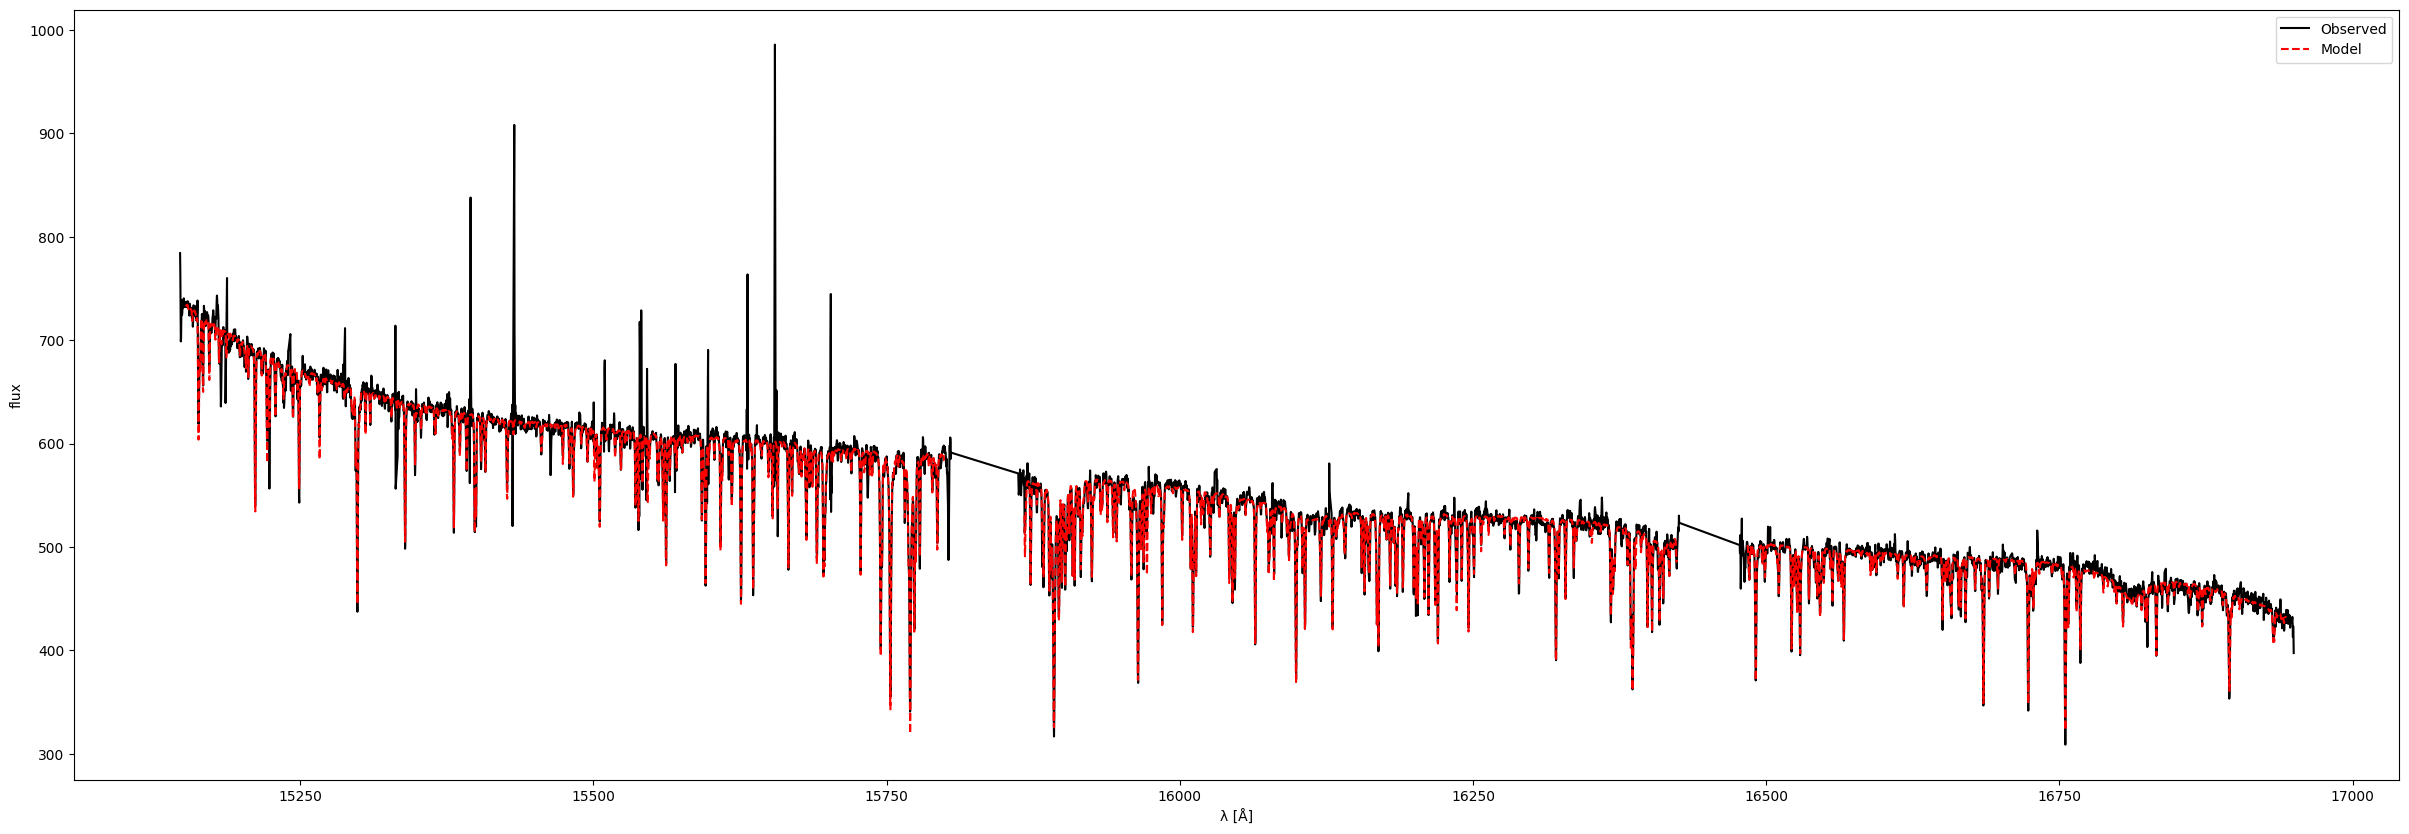

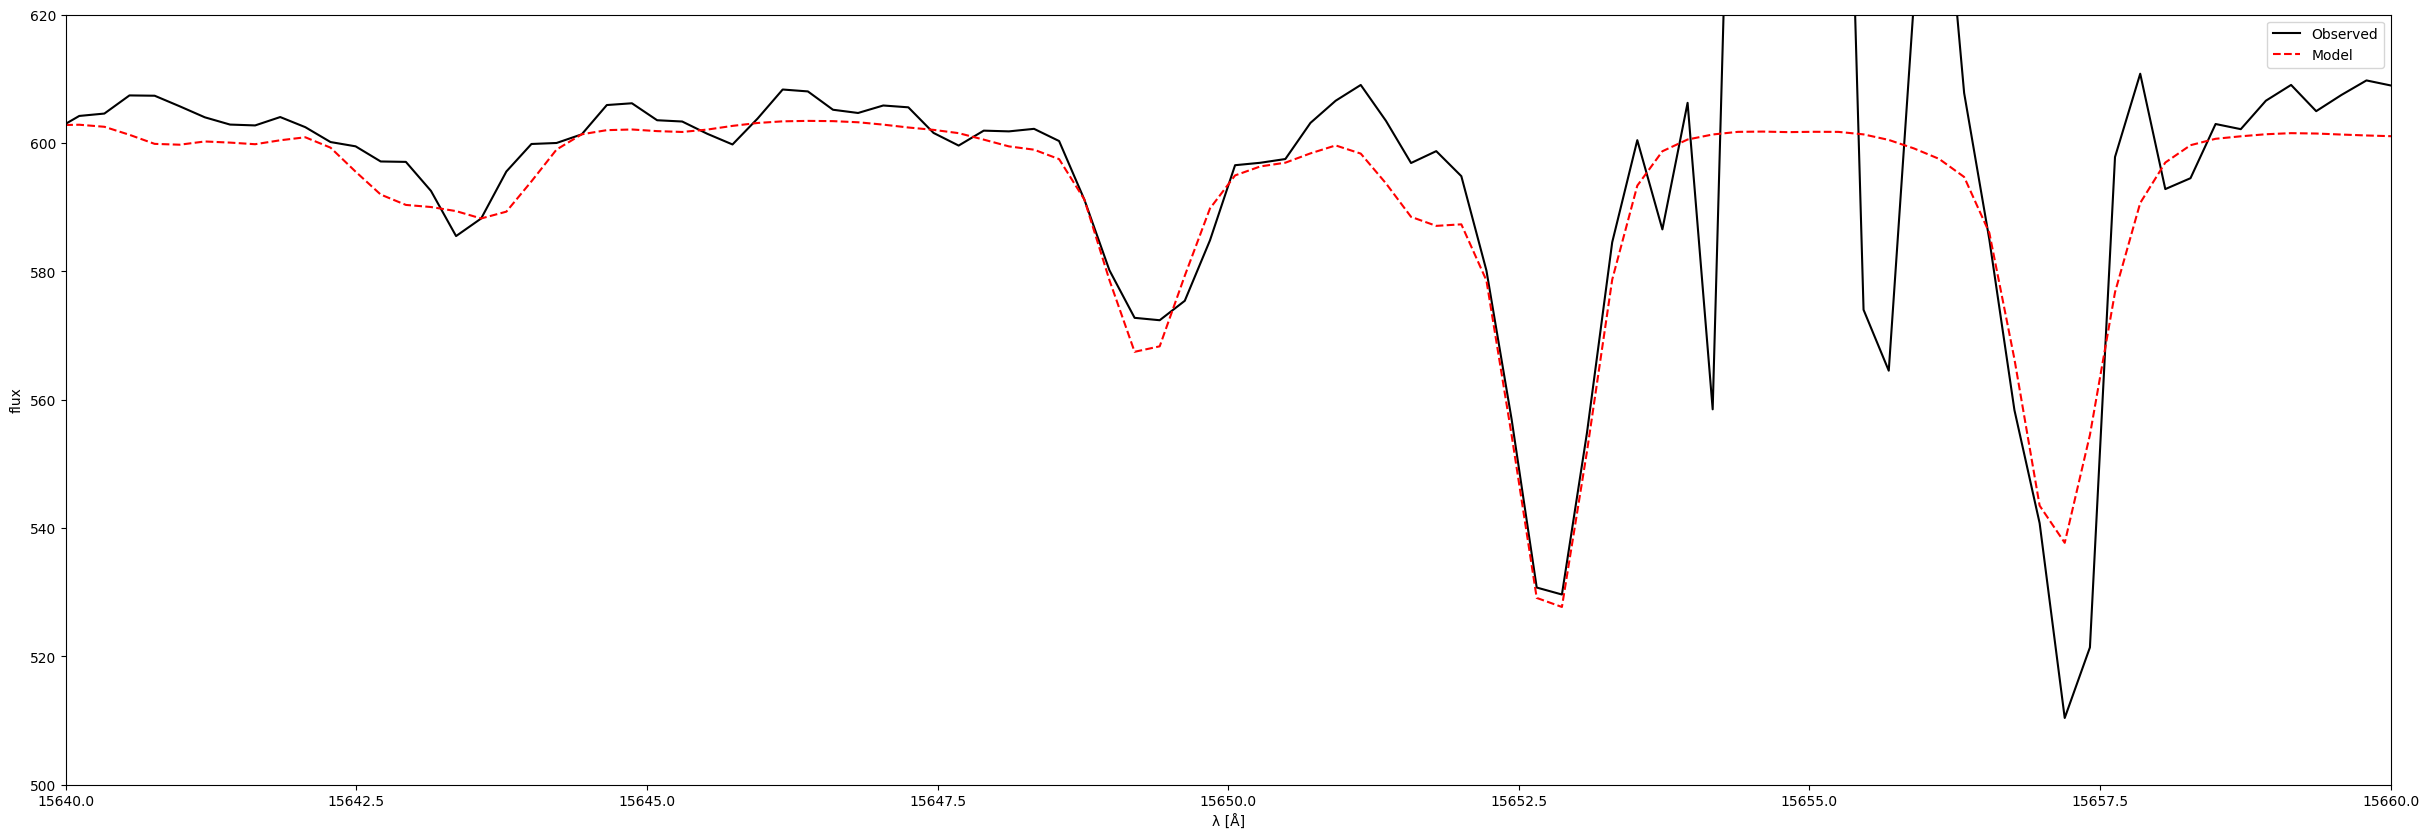

In [6]:
wavelength = aspcapStar["wavelength"][0]
model = aspcapStar["model_flux"][0]
continuum = aspcapStar["continuum"][0]

obs_wl = mwmStar["wavelength"][0]
obs_flux = mwmStar["flux"][0]
obs_err = mwmStar["ivar"][0]**(-0.5)

mask = obs_err < 0.1 * obs_flux

plt.figure(figsize=(30, 10))
plt.plot(obs_wl[mask], obs_flux[mask], c='k', label='Observed')
plt.plot(wavelength, model * continuum, linestyle="--", label="Model", c='r')
plt.xlabel("λ [Å]")
plt.ylabel("flux")
plt.legend()
plt.show()

plt.figure(figsize=(30, 10))
plt.plot(obs_wl[mask], obs_flux[mask], c='k', label='Observed')
plt.plot(wavelength, model * continuum, linestyle="--", label="Model", c='r')
plt.xlabel("λ [Å]")
plt.ylabel("flux")
plt.ylim(500, 620)
plt.xlim(15640, 15660)
plt.legend()
plt.show()

## BOSS Block File Spectra of M Dwarfs


In this demo, we are going to look at some spectra of M dwarfs! We will do this within DR20. One added product of DR20 made available to the collabroation is the block file! This includes all mwmStar spectra into one HDF5 file, which makes loading many spectra easy.

First though, to find some M dwarfs let's select some based on Gaia photometry. Luckily, the astra files, like `mwmAllStar` have this sort of meta-data to allow us to make a sensible selection. Below we will load the file, and then select stars with the highest SNR in bins of $G-RP$ for some $M_G$ value.

In [7]:
# load the file
sdss_path = sdss_access.path.Path(release='dr20',
                                  preserve_envvars=True)

mwmAllStar_path = sdss_path.full('mwmAllStar', v_astra='0.8.1')

mwmAllStar = Table.read(mwmAllStar_path, hdu=1)

In [8]:
MG = mwmAllStar['g_mag'] + 5 * np.log10(1e-3 * mwmAllStar['plx']) + 5
G_RP = mwmAllStar['g_mag'] - mwmAllStar['rp_mag']

MG_cut = (MG > 9.75) & (MG < 10.25)

G_RP_bins = np.linspace(1, 1.25, 11)

sdss_ids = []

for i in range(len(G_RP_bins) - 1):
    G_RP_cut =  (G_RP > G_RP_bins[i]) & (G_RP < G_RP_bins[i + 1])
    mwmAllStar_cut = mwmAllStar[MG_cut & G_RP_cut]
    if len(mwmAllStar_cut) > 0:
        idsort = np.argsort(mwmAllStar_cut['snr'])
        sdss_ids.append(mwmAllStar_cut['sdss_id'][idsort[-1]])

[WARNING]: invalid value encountered in log10 (RuntimeWarning)


Now let's load the block file! This is not within `sdss_access`, so has to be loaded manually.

In [9]:
block = h5py.File('/home/jovyan/data/release/dr20/spectro/astra/0.8.1/spectra/block/mwmStarBlock-0.8.1.h5', 'r')

Just like that, all spectra are loaded! Now let's plot the M dwarfs in the color cut!

[WARNING]: divide by zero encountered in divide (RuntimeWarning)
[WARNING]: invalid value encountered in divide (RuntimeWarning)


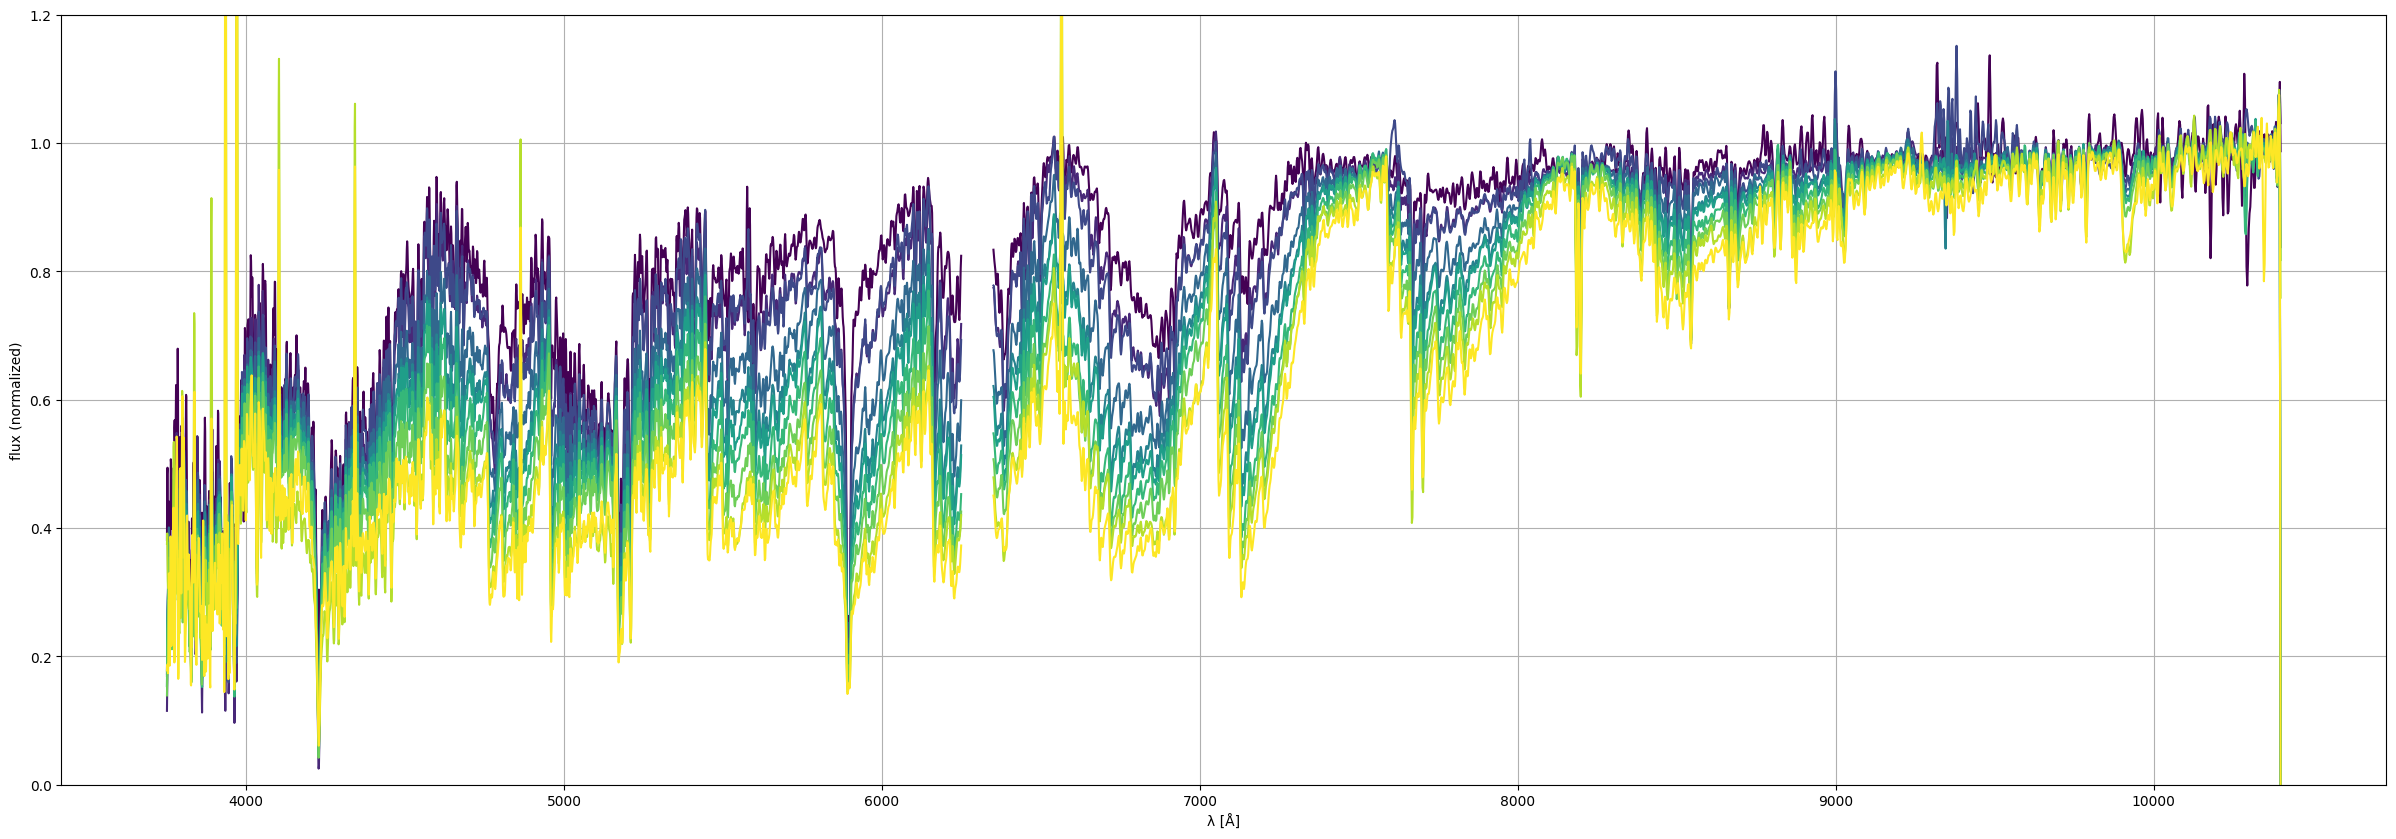

In [10]:
wave = block['boss']['spectra']['wavelength'][:]

cmap = plt.cm.viridis
n = len(sdss_ids)

colors = cmap(np.linspace(0, 1, n))

plt.figure(figsize=(30, 10))
for sdss_id, color in zip(sdss_ids, colors):
    idx = np.where(block['boss']['meta']['sdss_id'][:] == sdss_id)[0][0]
    plt.plot(wave,  block['boss']['spectra']['flux'][idx] / block['boss']['spectra']['continuum'][idx], c=color)
plt.grid()
plt.xlabel("λ [Å]")
plt.ylabel("flux (normalized)")
plt.ylim(0, 1.2)
plt.show()

Look at that nice gradient from metal-poor to metal-rich!